# Mathematical Engineering — Financial Engineering, FY 2025-2026

## Buy Side, Lab 4b — Risk-Based Allocation Strategies

This notebook implements and analyses risk-based allocation strategies on the Euro Stoxx 50 universe with monthly rebalancing and a 2-year rolling estimation window.

**Outline** 

0. Setup & rolling estimators
1. Part I — Equal Risk Contribution (ERC)
2. Part II — Hierarchical Risk Parity (HRP):
   1. Detoning intuition
   2. Cluster stability across rebalances (Rand index)
   3. Sensitivity to clustering choice and to the volatility allocation scheme
3. Part III — Connecting the dots: ERC vs HRP head-to-head and the role of shrinkage


## 0. Setup


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
from sklearn.metrics import rand_score

from utilities.backtest import backtest, portfolio_returns
from utilities.covariance_utilities import (
    prepare_rolling_estimation_window,
    covariance_to_correlation,
    risk_contribution,
)
from utilities.hierarchical_clustering import hierarchical_clustering
from utilities.hierarchical_risk_parity import (
    correlation_to_hrp_distance,
    dendrogram_iteration,
    hierarchical_risk_parity,
    recursive_bisection,
)
from utilities.portfolio_optimization import (
    equal_risk_contribution_portfolio,
    inverse_volatility_portfolio,
    minimum_variance_portfolio
)
from utilities.principal_component_analysis import (
    detone,
    principal_component_analysis,
)
from utilities.shrinkage import constant_corr_shrinkage, market_factor_shrinkage


In [2]:
# Read prices, compute daily simple returns
data_path = Path("C:\\Users\\fabar\\OneDrive\\Desktop\\AssignmentsFINENG\\Assignment4b_Group2BS\\data") 
last_prices = pd.read_csv(
    data_path / "sx5e_underlyings.csv", index_col="Date", parse_dates=True
)
last_prices = last_prices.ffill()
performance = last_prices.pct_change(fill_method=None).iloc[1:]


In [3]:
# Estimation parameters
estimation_window = 252  * 2 # TWO YEARS of trading days
min_coverage = 0.95  # asset must have >=95% non-NaN in the window
trading_days = 252

# Rebalance on the last trading day of each month
rebalance_dates = pd.DatetimeIndex(
    performance.groupby(pd.Grouper(freq="ME"))
    .apply(lambda x: x.index[-1] if len(x) > 0 else None)
    .dropna()
    .values
)


## 1. Pre-computation: rolling covariance estimators

For each rebalance date we estimate three covariance matrices on the trailing 2-year window:

- **sample** — plain `cov()`,
- **constant_corr** — Ledoit–Wolf (2003) constant-correlation shrinkage,
- **mkt_factor** — Ledoit–Wolf (2002) single-factor shrinkage with the
  equally-weighted return of the surviving universe used as the market
  proxy.

The asset universe at every rebalance is restricted to names with
≥95% non-missing observations in the window.


In [4]:
covariances = {}  
universes = {}  

for rebalance_date in rebalance_dates:
    cur_returns, diag = prepare_rolling_estimation_window(
        returns=performance,
        rebalance_date=rebalance_date,
        lookback=estimation_window,
        min_coverage=min_coverage,
        return_diagnostics=True,
    )
    if diag["row_count"] < estimation_window or cur_returns.shape[1] == 0:
        continue

    reb = rebalance_date.to_pydatetime().date()

    universes[reb] = list(cur_returns.columns)

    covariances[reb] = {
        "sample": cur_returns.cov(),
        "constant_corr": constant_corr_shrinkage(cur_returns)["shrunk_cov"],
        "mkt_factor": market_factor_shrinkage(
            cur_returns,
            market_returns=cur_returns.mean(axis=1),
        )["shrunk_cov"],
    }

all_dates = sorted(covariances.keys())

In [5]:
print(f"Rebalance dates total       : {len(rebalance_dates)}")
print(f"Rebalance dates kept        : {len(all_dates)}")
print(f"First valid date            : {all_dates[0]}")
print(f"Last valid date             : {all_dates[-1]}")

# Universe size over time
universe_sizes = pd.Series(
    {d: len(universes[d]) for d in all_dates}, name="universe_size"
)
print(f"\nUniverse size  min/median/max: "
      f"{universe_sizes.min()} / {int(universe_sizes.median())} / {universe_sizes.max()}")

Rebalance dates total       : 122
Rebalance dates kept        : 99
First valid date            : 2014-12-31
Last valid date             : 2023-02-17

Universe size  min/median/max: 46 / 47 / 50


## Part I — Equal Risk Contribution (ERC)


### 1.b Sanity check: Risk contribution dispersion & IV ≡ ERC under a diagonal Σ


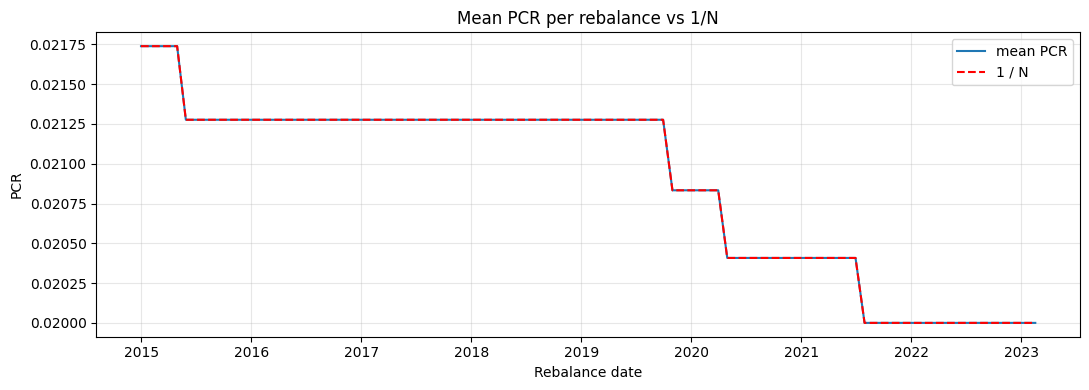

In [6]:
iv_erc_delta = {}
erc_normalized_range = {}
pcr_to_plot = {}

for date in all_dates:
    cov = covariances[date]["sample"].values

    # (1) IV ≡ ERC under diagonal Σ
    diag_cov = np.diag(np.diag(cov))
    w_iv  = inverse_volatility_portfolio(cov)
    w_erc_diag = equal_risk_contribution_portfolio(diag_cov)
    iv_erc_delta[date] = np.linalg.norm(w_iv - w_erc_diag, ord=1)

    # (2) Risk-contribution dispersion of the actual ERC solution
    w_erc = equal_risk_contribution_portfolio(cov)
    rc = risk_contribution(w_erc.reshape(1, -1), cov).flatten()
    erc_normalized_range[date] = (rc.max() - rc.min()) / rc.sum()

    # (3) Plot PCR and check ~ 1/n_assets
    portfolio_vol = rc.sum()
    pcr = rc / portfolio_vol
    pcr_to_plot[date] = pcr.mean()


# pcr_to_plot is dict: {date: mean_pcr}
pcr_series = pd.Series(pcr_to_plot).sort_index()

# 1/N at each date — universe size changes over time
inv_n_series = pd.Series(
    {d: 1.0 / len(universes[d]) for d in pcr_series.index}
)

fig, ax = plt.subplots(figsize=(11, 4))
pcr_series.plot(ax=ax, label="mean PCR")
inv_n_series.plot(ax=ax, label="1 / N", linestyle="--", color="red")
ax.set_title("Mean PCR per rebalance vs 1/N")
ax.set_xlabel("Rebalance date")
ax.set_ylabel("PCR")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
    


In [7]:
iv_erc_delta_s = pd.Series(iv_erc_delta).sort_index()
erc_disp_s     = pd.Series(erc_normalized_range).sort_index()

print("=" * 60)
print("Sanity check 1 — IV ≡ ERC under diagonal Σ")
print("=" * 60)
print(f"  L1 distance ||w_IV - w_ERC||_1 across all rebalances:")
print(f"     mean : {iv_erc_delta_s.mean():.2e}")
print(f"     max  : {iv_erc_delta_s.max():.2e}")
print(f"     date of max : {iv_erc_delta_s.idxmax()}")

print()
print("=" * 60)
print("Sanity check 2 — ERC risk-contribution dispersion (real Σ)")
print("=" * 60)
print(f"  Normalized range (RC_max - RC_min) / sum(RC):")
print(f"     mean : {erc_disp_s.mean():.2e}")
print(f"     max  : {erc_disp_s.max():.2e}")
print(f"     date of max : {erc_disp_s.idxmax()}")

Sanity check 1 — IV ≡ ERC under diagonal Σ
  L1 distance ||w_IV - w_ERC||_1 across all rebalances:
     mean : 1.05e-16
     max  : 4.48e-16
     date of max : 2016-05-31

Sanity check 2 — ERC risk-contribution dispersion (real Σ)
  Normalized range (RC_max - RC_min) / sum(RC):
     mean : 1.59e-02
     max  : 2.00e-02
     date of max : 2019-04-30


### 1.c ERC backtest across the three covariance estimators


In [8]:
erc_portfolios = {"sample": {}, "constant_corr": {}, "mkt_factor": {}}

for reb in all_dates:
    universe = universes[reb]
    for est_name, cov in covariances[reb].items():
        weights = equal_risk_contribution_portfolio(cov.values)
        erc_portfolios[est_name][reb] = pd.Series(weights, index=universe)

In [9]:
# Stack the per-date Series into one DataFrame per estimator
erc_weights = {
    est: pd.DataFrame(d).T.sort_index()
    for est, d in erc_portfolios.items()
}
# .T because pd.DataFrame({date: series}) makes dates columns;
# we want dates on the index, assets on the columns.

# Backtest: cumulative wealth and per-day returns
erc_cum    = {est: backtest(w, performance)         for est, w in erc_weights.items()}
erc_rets   = {est: portfolio_returns(w, performance) for est, w in erc_weights.items()}


erc_cum_df  = pd.DataFrame(erc_cum)
erc_rets_df = pd.DataFrame(erc_rets)

# 63-day EWM realized volatility, annualized
erc_vol_df = (
    erc_rets_df
    .ewm(span=63, adjust=False).std()
    .mul(np.sqrt(trading_days))
)

# Drawdown: current wealth relative to running max
erc_dd_df = erc_cum_df.div(erc_cum_df.cummax()).sub(1.0)

# Turnover: L1 weight change between consecutive rebalances, per estimator
def compute_turnover(weights_df: pd.DataFrame) -> pd.Series:
    aligned = weights_df.fillna(0.0)
    return aligned.diff().abs().sum(axis=1).iloc[1:]   # drop first NaN row

erc_turnover_df = pd.DataFrame(
    {est: compute_turnover(w) for est, w in erc_weights.items()}
)

# Summary table
summary = pd.DataFrame({
    "total_return"   : erc_cum_df.iloc[-1] - 1,
    "ann_return"     : erc_cum_df.iloc[-1] ** (trading_days / len(erc_cum_df)) - 1,
    "ann_vol_avg"    : erc_vol_df.mean(),
    "max_drawdown"   : erc_dd_df.min(),
    "avg_turnover"   : erc_turnover_df.mean(),
}).round(4)

print("ERC backtest summary across estimators:")
print(summary)

ERC backtest summary across estimators:
               total_return  ann_return  ann_vol_avg  max_drawdown  \
sample               1.0028      0.0875       0.1759        -0.395   
constant_corr        1.0028      0.0875       0.1759        -0.395   
mkt_factor           1.0028      0.0875       0.1759        -0.395   

               avg_turnover  
sample               0.0141  
constant_corr        0.0141  
mkt_factor           0.0141  


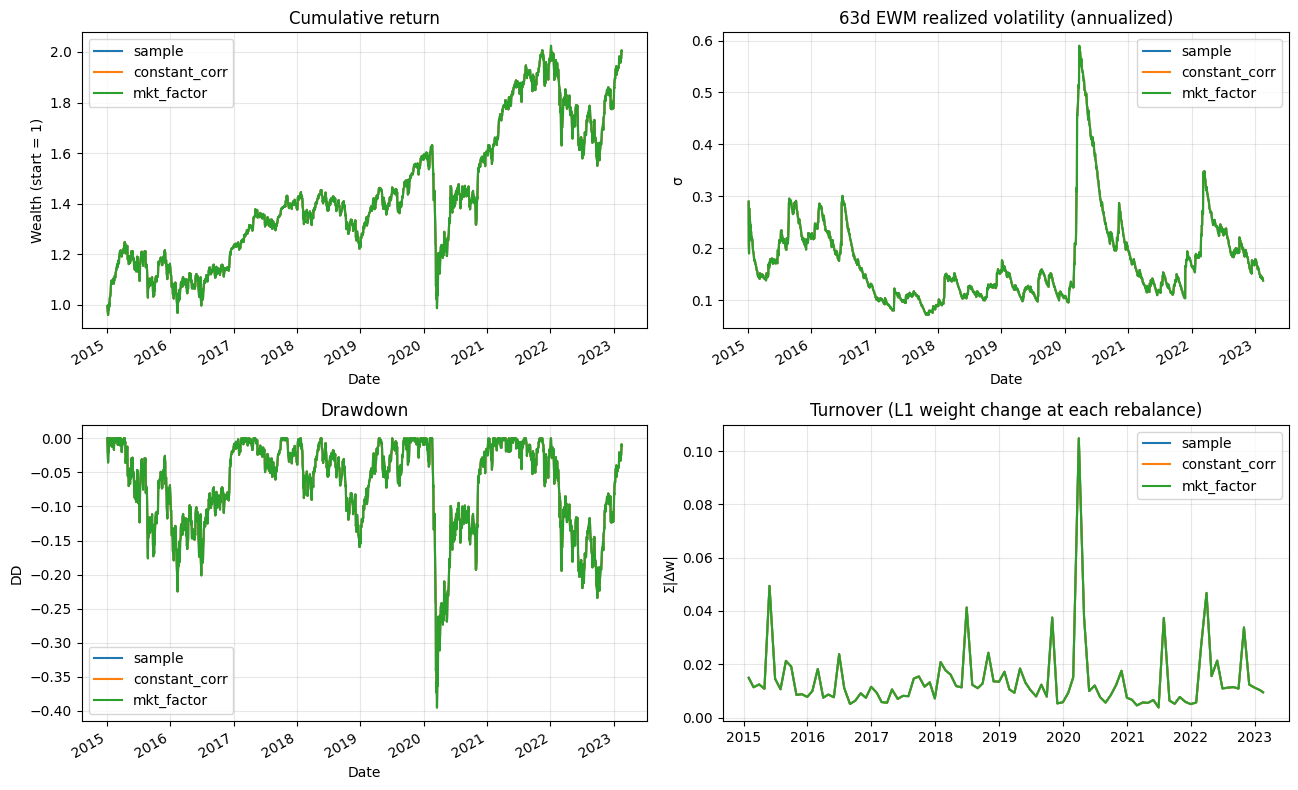

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

erc_cum_df.plot(ax=axes[0, 0])
axes[0, 0].set_title("Cumulative return")
axes[0, 0].set_ylabel("Wealth (start = 1)"); axes[0, 0].grid(alpha=0.3)

erc_vol_df.plot(ax=axes[0, 1])
axes[0, 1].set_title("63d EWM realized volatility (annualized)")
axes[0, 1].set_ylabel("σ"); axes[0, 1].grid(alpha=0.3)

erc_dd_df.plot(ax=axes[1, 0])
axes[1, 0].set_title("Drawdown")
axes[1, 0].set_ylabel("DD"); axes[1, 0].grid(alpha=0.3)

erc_turnover_df.plot(ax=axes[1, 1])
axes[1, 1].set_title("Turnover (L1 weight change at each rebalance)")
axes[1, 1].set_ylabel("Σ|Δw|"); axes[1, 1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

## Part II — Hierarchical Risk Parity (HRP)


### 2.a Detoning — intuition


In [11]:
# --- Setup: pick last rebalance, get sample covariance, build correlation ---
last_date = all_dates[-1]
cov_last = covariances[last_date]["sample"]
universe_last = universes[last_date]

# Raw correlation matrix
corr_raw = pd.DataFrame(
    covariance_to_correlation(cov_last.values),
    index=universe_last,
    columns=universe_last,
)

# Detoned correlation matrix (first PC removed)
corr_detoned = pd.DataFrame(
    detone(corr_raw.values, components_num=1),
    index=universe_last,
    columns=universe_last,
)

# --- Build linkage matrices on the HRP distance of each correlation ---
LINKAGE = "ward"
METRIC = "euclidean"

dist_raw = pd.DataFrame(
    correlation_to_hrp_distance(corr_raw.values),
    index=universe_last,
    columns=universe_last,
)
dist_detoned = pd.DataFrame(
    correlation_to_hrp_distance(corr_detoned.values),
    index=universe_last,
    columns=universe_last,
)

link_raw = hierarchical_clustering(
    matrix=dist_raw, linkage_method=LINKAGE, distance_metric=METRIC
)
link_detoned = hierarchical_clustering(
    matrix=dist_detoned, linkage_method=LINKAGE, distance_metric=METRIC
)

# --- Quasi-diagonalize: reorder rows and columns by dendrogram leaf order ---
order_raw = sch.leaves_list(link_raw.values)
order_detoned = sch.leaves_list(link_detoned.values)

corr_raw_qd = corr_raw.iloc[order_raw, order_raw]
corr_detoned_qd = corr_detoned.iloc[order_detoned, order_detoned]

c:\Users\fabar\OneDrive\Desktop\AssignmentsFINENG\Assignment4b_Group2BS\utilities\hierarchical_clustering.py:29: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = sch.linkage(
c:\Users\fabar\OneDrive\Desktop\AssignmentsFINENG\Assignment4b_Group2BS\utilities\hierarchical_clustering.py:29: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = sch.linkage(


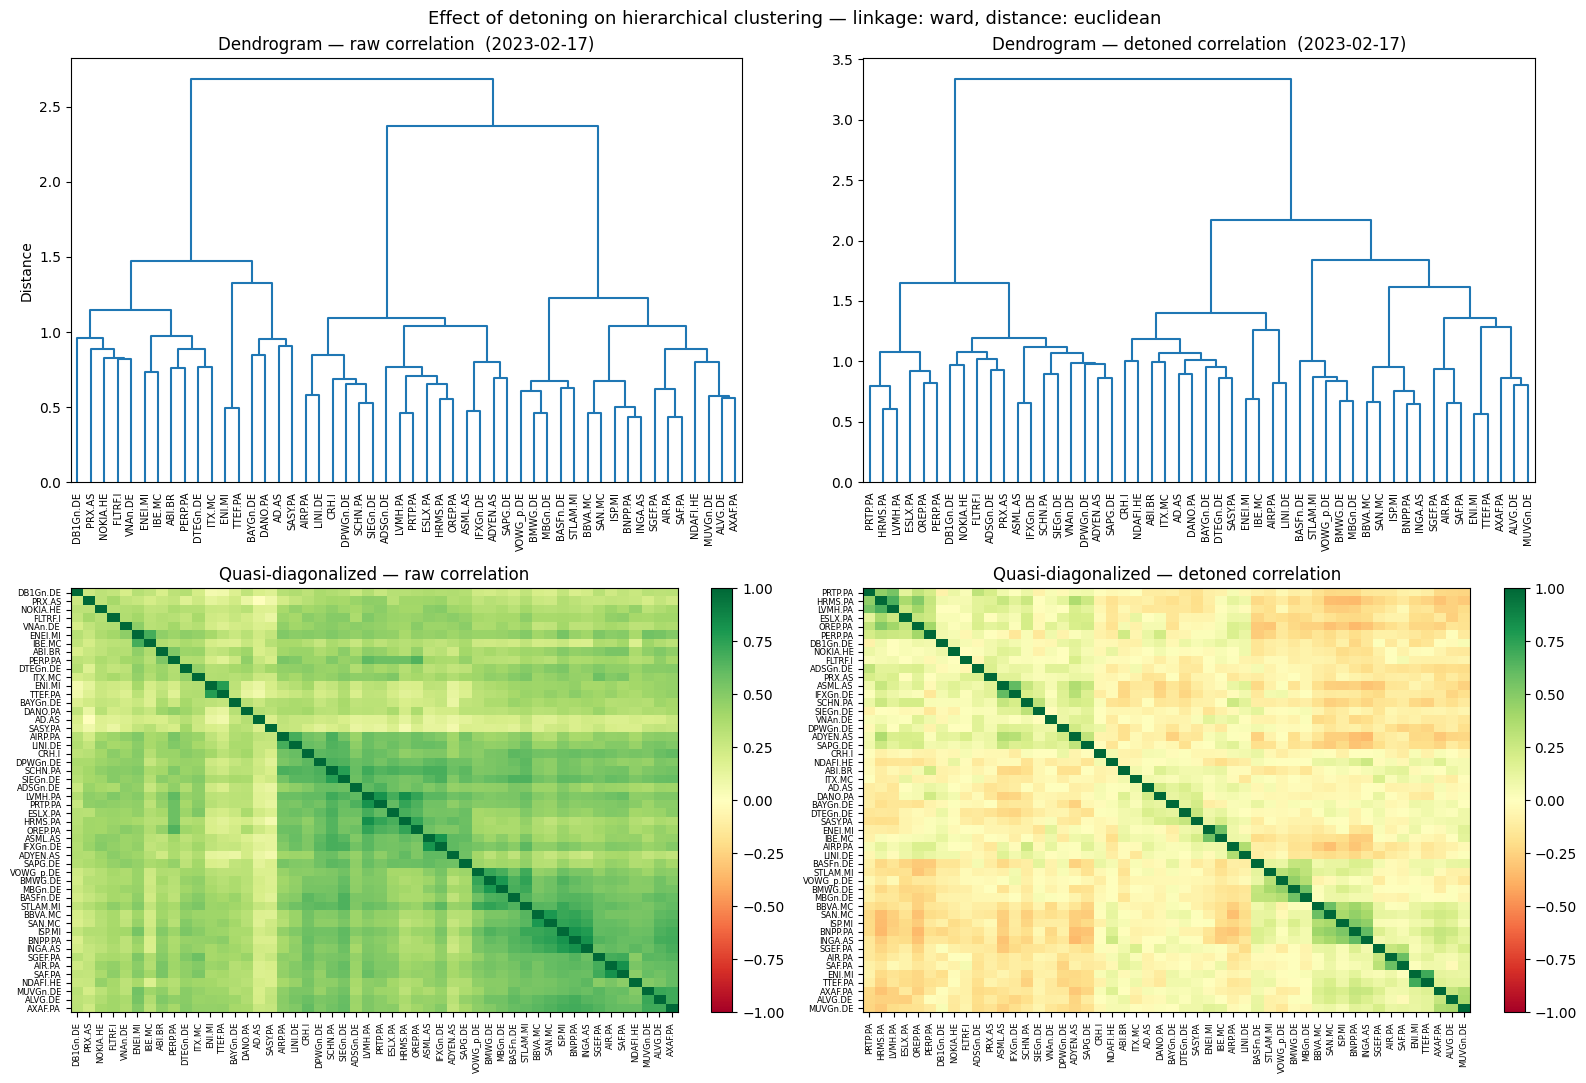

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Top row: dendrograms
sch.dendrogram(
    link_raw.values, labels=corr_raw.index.tolist(), ax=axes[0, 0],
    color_threshold=0, leaf_rotation=90, leaf_font_size=7,
)
axes[0, 0].set_title(f"Dendrogram — raw correlation  ({last_date})")
axes[0, 0].set_ylabel("Distance")

sch.dendrogram(
    link_detoned.values, labels=corr_detoned.index.tolist(), ax=axes[0, 1],
    color_threshold=0, leaf_rotation=90, leaf_font_size=7,
)
axes[0, 1].set_title(f"Dendrogram — detoned correlation  ({last_date})")

# Bottom row: quasi-diagonalized correlation heatmaps
im0 = axes[1, 0].imshow(corr_raw_qd.values, cmap="RdYlGn", vmin=-1, vmax=1, aspect="auto")
axes[1, 0].set_title("Quasi-diagonalized — raw correlation")
axes[1, 0].set_xticks(range(len(corr_raw_qd))); axes[1, 0].set_xticklabels(corr_raw_qd.columns, rotation=90, fontsize=6)
axes[1, 0].set_yticks(range(len(corr_raw_qd))); axes[1, 0].set_yticklabels(corr_raw_qd.index, fontsize=6)
plt.colorbar(im0, ax=axes[1, 0], fraction=0.046)

im1 = axes[1, 1].imshow(corr_detoned_qd.values, cmap="RdYlGn", vmin=-1, vmax=1, aspect="auto")
axes[1, 1].set_title("Quasi-diagonalized — detoned correlation")
axes[1, 1].set_xticks(range(len(corr_detoned_qd))); axes[1, 1].set_xticklabels(corr_detoned_qd.columns, rotation=90, fontsize=6)
axes[1, 1].set_yticks(range(len(corr_detoned_qd))); axes[1, 1].set_yticklabels(corr_detoned_qd.index, fontsize=6)
plt.colorbar(im1, ax=axes[1, 1], fraction=0.046)

plt.suptitle(
    f"Effect of detoning on hierarchical clustering — linkage: {LINKAGE}, distance: {METRIC}",
    fontsize=13,
)
plt.tight_layout()
plt.show()

### 2.c Cluster stability across rebalances (Rand index)

We measure how stable the clustering is between consecutive rebalances via the Rand index. A value close to 1 means the partition into $k$ clusters changes little month-to-month.


c:\Users\fabar\OneDrive\Desktop\AssignmentsFINENG\Assignment4b_Group2BS\utilities\hierarchical_clustering.py:29: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = sch.linkage(
c:\Users\fabar\OneDrive\Desktop\AssignmentsFINENG\Assignment4b_Group2BS\utilities\hierarchical_clustering.py:29: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = sch.linkage(
c:\Users\fabar\OneDrive\Desktop\AssignmentsFINENG\Assignment4b_Group2BS\utilities\hierarchical_clustering.py:29: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = sch.linkage(
c:\Users\fabar\OneDrive\Desktop\AssignmentsFINENG\Assignment4b_Group2BS\utilities\hierarchical_clustering.py:29: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspi

Average Rand index across all rebalances:
k                        5      8      10     15
cov_key       detone                            
constant_corr False   0.904  0.929  0.948  0.972
              True    0.878  0.928  0.949  0.978
mkt_factor    False   0.902  0.927  0.941  0.967
              True    0.876  0.925  0.945  0.979
sample        False   0.893  0.927  0.944  0.971
              True    0.866  0.923  0.943  0.978


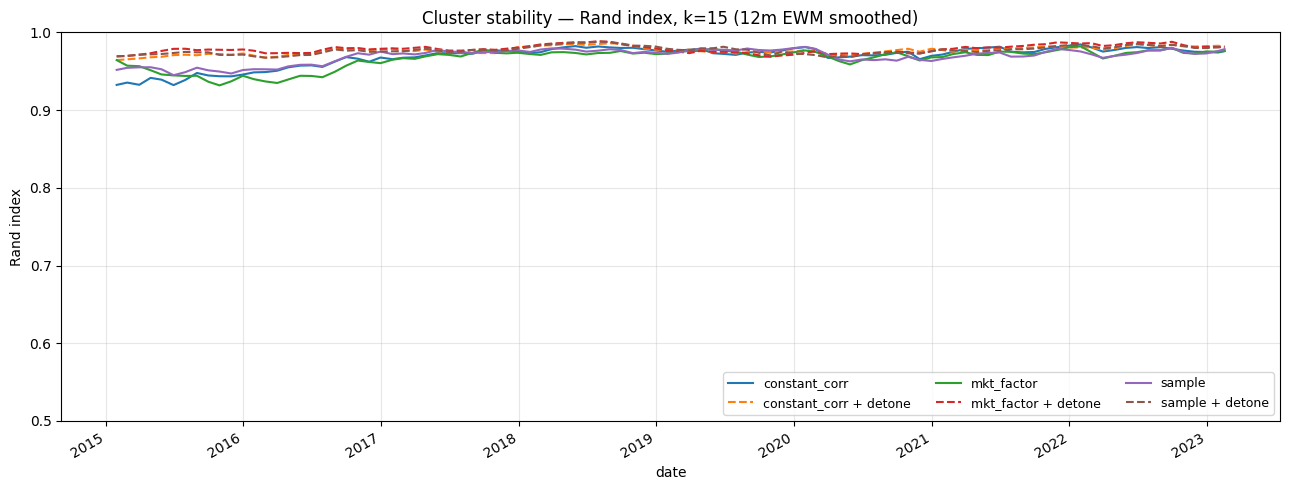

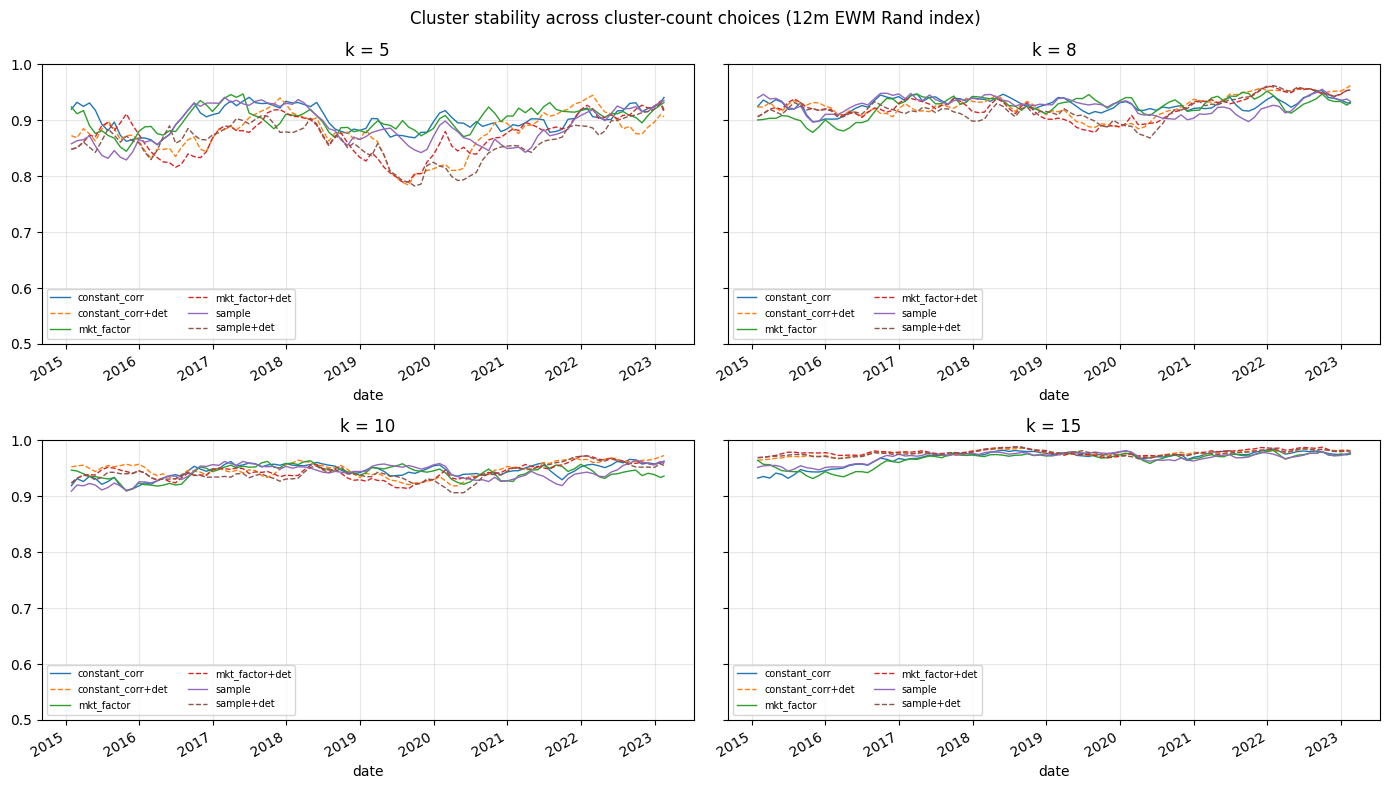

In [13]:

#import warnings
#from scipy.cluster.hierarchy import ClusterWarning
#warnings.filterwarnings("ignore", category=ClusterWarning)


LINKAGE_METHOD = "ward"
DIST_METRIC = "euclidean"
N_CLUSTERS_GRID = [5, 8, 10, 15]
N_CLUSTERS_FOCUS = 15
COV_KEYS = ["sample", "constant_corr", "mkt_factor"]
DETONE_KEYS = [False, True]


linkages = {(c, d): {} for c in COV_KEYS for d in DETONE_KEYS}
clusters = {
    (c, d, k): {} for c in COV_KEYS for d in DETONE_KEYS for k in N_CLUSTERS_GRID
}

for reb in all_dates:
    for cov_key in COV_KEYS:
        cov = covariances[reb][cov_key]
        for detone_flag in DETONE_KEYS:

            correlation = covariance_to_correlation(cov.values)
            if detone_flag:
                correlation = detone(correlation, components_num=1)

            distance = correlation_to_hrp_distance(correlation)
            distance_df = pd.DataFrame(
                distance, index=cov.index, columns=cov.columns
            )

            link = hierarchical_clustering(
                matrix=distance_df,
                linkage_method=LINKAGE_METHOD,
                distance_metric=DIST_METRIC,
            )
              # !!! COMPLETE AS APPROPRIATE !!!
            linkages[(cov_key, detone_flag)][reb] = link
            for n_clusters in N_CLUSTERS_GRID:
                clusters[(cov_key, detone_flag, n_clusters)][reb] = pd.Series(
                    sch.cut_tree(link.values, n_clusters=n_clusters).flatten(),
                    index=cov.index,
                )



# --- Compute pairwise Rand index between consecutive rebalances ---
rand_records = []

for cov_key in COV_KEYS:
    for detone_flag in DETONE_KEYS:
        for k in N_CLUSTERS_GRID:
            partition_series = clusters[(cov_key, detone_flag, k)]
            sorted_dates = sorted(partition_series.keys())

            for prev_date, curr_date in zip(sorted_dates[:-1], sorted_dates[1:]):
                prev_p = partition_series[prev_date]
                curr_p = partition_series[curr_date]

                # Restrict to assets present in both rebalances
                common = prev_p.index.intersection(curr_p.index)
                if len(common) < 2:
                    continue

                rand = rand_score(
                    prev_p.loc[common].values,
                    curr_p.loc[common].values,
                )
                rand_records.append({
                    "date": curr_date,
                    "cov_key": cov_key,
                    "detone": detone_flag,
                    "k": k,
                    "rand": rand,
                })

rand_df = pd.DataFrame(rand_records)
rand_df["date"] = pd.to_datetime(rand_df["date"])

# --- Summary table: average Rand index by configuration ---
summary = (
    rand_df.groupby(["cov_key", "detone", "k"])["rand"].mean()
    .unstack("k").round(3)
)
print("Average Rand index across all rebalances:")
print(summary)

# --- 12m EWM smoothed time series, focus on k = N_CLUSTERS_FOCUS ---
focus = rand_df[rand_df["k"] == N_CLUSTERS_FOCUS].pivot_table(
    index="date", columns=["cov_key", "detone"], values="rand"
).sort_index()
smoothed = focus.ewm(span=12, adjust=False).mean()

fig, ax = plt.subplots(figsize=(13, 5))
for col in smoothed.columns:
    cov_key, detone_flag = col
    label = f"{cov_key}{' + detone' if detone_flag else ''}"
    linestyle = "--" if detone_flag else "-"
    smoothed[col].plot(ax=ax, label=label, linestyle=linestyle)

ax.set_title(f"Cluster stability — Rand index, k={N_CLUSTERS_FOCUS} (12m EWM smoothed)")
ax.set_ylabel("Rand index")
ax.set_ylim(0.5, 1.0)
ax.legend(loc="lower right", ncol=3, fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- Small multiples: one panel per k ---
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=True)
axes = axes.flatten()

for ax, k in zip(axes, N_CLUSTERS_GRID):
    sub = rand_df[rand_df["k"] == k].pivot_table(
        index="date", columns=["cov_key", "detone"], values="rand"
    ).sort_index()
    sm = sub.ewm(span=12, adjust=False).mean()
    for col in sm.columns:
        cov_key, detone_flag = col
        label = f"{cov_key}{'+det' if detone_flag else ''}"
        linestyle = "--" if detone_flag else "-"
        sm[col].plot(ax=ax, label=label, linestyle=linestyle, linewidth=1)
    ax.set_title(f"k = {k}")
    ax.set_ylim(0.5, 1.0)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7, ncol=2)

plt.suptitle("Cluster stability across cluster-count choices (12m EWM Rand index)", fontsize=12)
plt.tight_layout()
plt.show()

*About the warnings*

After reading the scipy documentation, we found that the `ClusterWarning` raised by `sch.linkage` is overly cautious. Scipy issues this warning whenever the input is a 2D matrix that *looks like* a precomputed distance matrix — i.e., symmetric, non-negative, and with zeros on the diagonal. Our HRP distance matrix has exactly these properties, but we are intentionally passing it as an **observation matrix**: each row is interpreted as an asset's distance profile to all other assets, and `sch.linkage` correctly computes the second-stage euclidean distance between these profiles. This is the standard two-stage HRP recipe by López de Prado.

The warning is therefore a false positive.

### 2.d Sensitivity of HRP weights — clustering vs. allocation traversal


c:\Users\fabar\OneDrive\Desktop\AssignmentsFINENG\Assignment4b_Group2BS\utilities\hierarchical_clustering.py:29: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = sch.linkage(
c:\Users\fabar\OneDrive\Desktop\AssignmentsFINENG\Assignment4b_Group2BS\utilities\hierarchical_clustering.py:29: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = sch.linkage(
c:\Users\fabar\OneDrive\Desktop\AssignmentsFINENG\Assignment4b_Group2BS\utilities\hierarchical_clustering.py:29: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = sch.linkage(
c:\Users\fabar\OneDrive\Desktop\AssignmentsFINENG\Assignment4b_Group2BS\utilities\hierarchical_clustering.py:29: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspi

HRP weight-sensitivity grid (48 configurations):
          cov_key   linkage             allocator  detone  mean_turnover  \
0          sample    single   recursive_bisection   False         0.2039   
1          sample    single   recursive_bisection    True         0.2404   
2          sample    single  dendrogram_iteration   False         0.2006   
3          sample    single  dendrogram_iteration    True         0.4851   
4          sample      ward   recursive_bisection   False         0.2112   
5          sample      ward   recursive_bisection    True         0.2254   
6          sample      ward  dendrogram_iteration   False         0.3133   
7          sample      ward  dendrogram_iteration    True         0.3501   
8          sample  complete   recursive_bisection   False         0.2338   
9          sample  complete   recursive_bisection    True         0.2322   
10         sample  complete  dendrogram_iteration   False         0.3156   
11         sample  complete  dendrogram

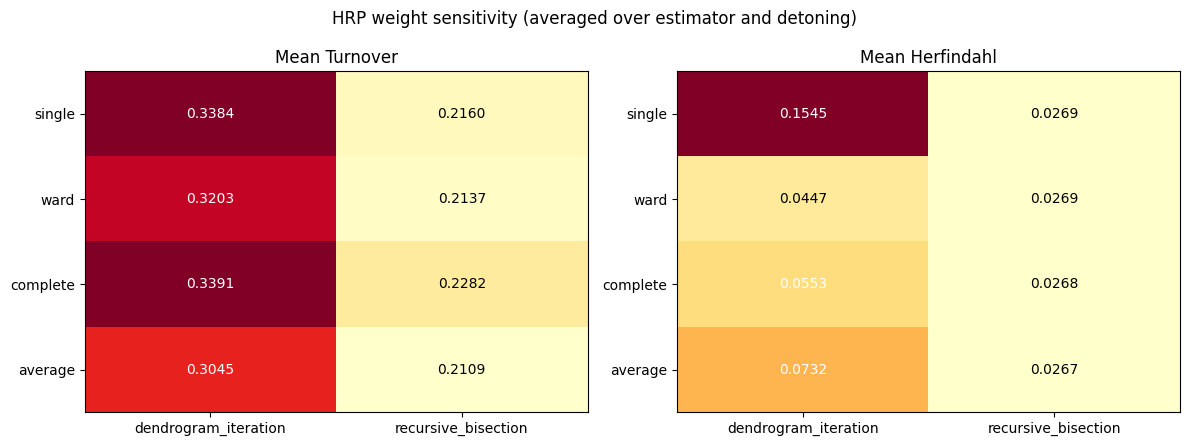

In [14]:
LINK_GRID = ["single", "ward", "complete", "average"]
ALLOC_GRID = {
    "recursive_bisection": recursive_bisection,
    "dendrogram_iteration": dendrogram_iteration,
}

hrp_grid = {}
for cov_key in COV_KEYS:
    for link in LINK_GRID:
        for alloc_name, alloc in ALLOC_GRID.items():
            for d in DETONE_KEYS:
                hrp_grid[(cov_key, link, alloc_name, d)] = {
                    reb: hierarchical_risk_parity(
                        covariance=covariances[reb][cov_key],
                        linkage_method=link,
                        distance_metric=DIST_METRIC,
                        cluster_traverser=alloc,
                        perform_detoning=d,
                    )
                    for reb in all_dates
                }

def hrp_turnover(weight_dict: dict) -> float:
    """Mean L1 weight change between consecutive rebalances."""
    sorted_dates = sorted(weight_dict.keys())
    diffs = []
    for prev_date, curr_date in zip(sorted_dates[:-1], sorted_dates[1:]):
        prev = weight_dict[prev_date]
        curr = weight_dict[curr_date]
        all_assets = prev.index.union(curr.index)
        diffs.append(
            (curr.reindex(all_assets, fill_value=0.0)
             - prev.reindex(all_assets, fill_value=0.0)).abs().sum()
        )
    return float(np.mean(diffs))

def hrp_herfindahl(weight_dict: dict) -> float:
    """Mean Herfindahl concentration index (sum of squared weights)."""
    return float(np.mean([(w ** 2).sum() for w in weight_dict.values()]))

records = []
for (cov_key, link, alloc_name, d), wd in hrp_grid.items():
    records.append({
        "cov_key"        : cov_key,
        "linkage"        : link,
        "allocator"      : alloc_name,
        "detone"         : d,
        "mean_turnover"  : hrp_turnover(wd),
        "mean_herfindahl": hrp_herfindahl(wd),
    })

grid_df = pd.DataFrame(records)
print("HRP weight-sensitivity grid (48 configurations):")
print(grid_df.round(4))




# Linkage × allocator (averaged over estimator and detoning)
view_link_alloc = grid_df.groupby(["linkage", "allocator"])[
    ["mean_turnover", "mean_herfindahl"]
].mean().round(4)
print("\n──────── Linkage × allocator effect ────────")
print(view_link_alloc)

# Estimator effect (averaged over everything else)
view_est = grid_df.groupby("cov_key")[
    ["mean_turnover", "mean_herfindahl"]
].mean().round(4)
print("\n──────── Estimator effect ────────")
print(view_est)

# Detoning effect at fixed linkage and allocator
view_det = grid_df.groupby(["linkage", "allocator", "detone"])[
    ["mean_turnover", "mean_herfindahl"]
].mean().round(4)
print("\n──────── Detoning effect ────────")
print(view_det)




fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, metric in zip(axes, ["mean_turnover", "mean_herfindahl"]):
    pivot = grid_df.pivot_table(
        index="linkage", columns="allocator", values=metric
    ).loc[LINK_GRID]
    im = ax.imshow(pivot.values, cmap="YlOrRd", aspect="auto")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_title(f"{metric.replace('_', ' ').title()}")
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            ax.text(j, i, f"{pivot.values[i, j]:.4f}",
                    ha="center", va="center", fontsize=10,
                    color="white" if pivot.values[i, j] > pivot.values.mean() else "black")

plt.suptitle("HRP weight sensitivity (averaged over estimator and detoning)", fontsize=12)
plt.tight_layout()
plt.show()


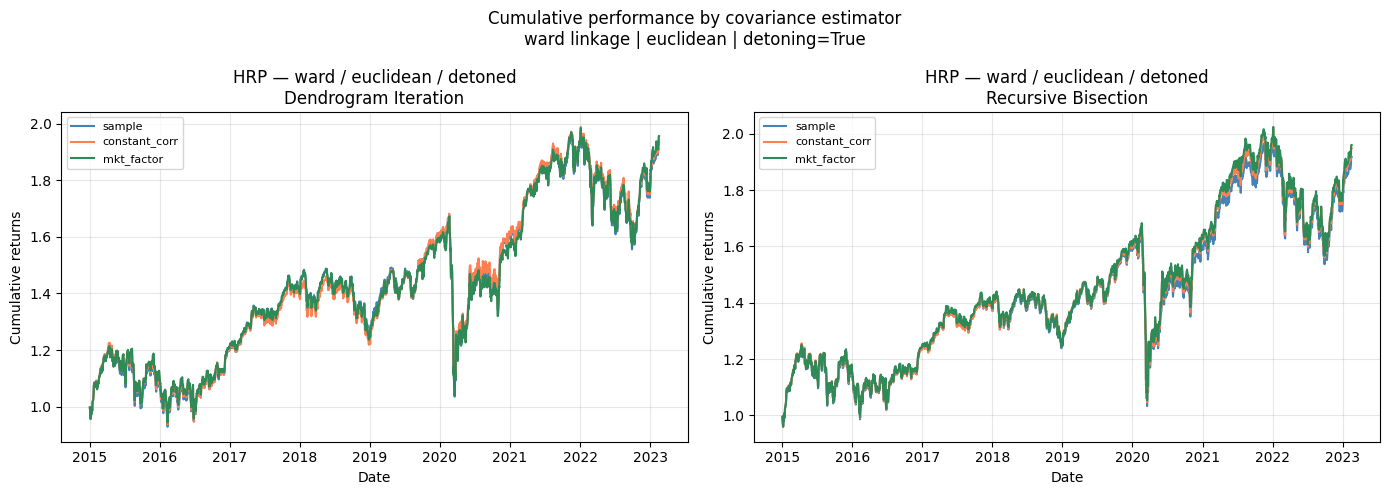

In [15]:
# ── Cumulative returns: ward / euclidean / detoned, by estimator ──────────────
# One panel per allocator, one line per covariance estimator

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

COLORS = {"sample": "steelblue", "constant_corr": "coral", "mkt_factor": "seagreen"}
ALLOC_TITLES = {
    "dendrogram_iteration": "Dendrogram Iteration",
    "recursive_bisection":  "Recursive Bisection",
}

for ax, alloc_name in zip(axes, ["dendrogram_iteration", "recursive_bisection"]):
    for cov_key, color in COLORS.items():
        key = (cov_key, "ward", alloc_name, True)
        weights_df = pd.DataFrame(hrp_grid[key]).T
        weights_df.index = pd.to_datetime(weights_df.index)
        weights_df = weights_df.sort_index()

        cum = backtest(weights_df, performance)
        ax.plot(cum.index, cum.values, color=color, lw=1.5, label=cov_key)

    ax.set_title(f"HRP — ward / euclidean / detoned\n{ALLOC_TITLES[alloc_name]}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Cumulative returns")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle("Cumulative performance by covariance estimator\n"
             "ward linkage | euclidean | detoning=True", fontsize=12)
plt.tight_layout()
plt.show()

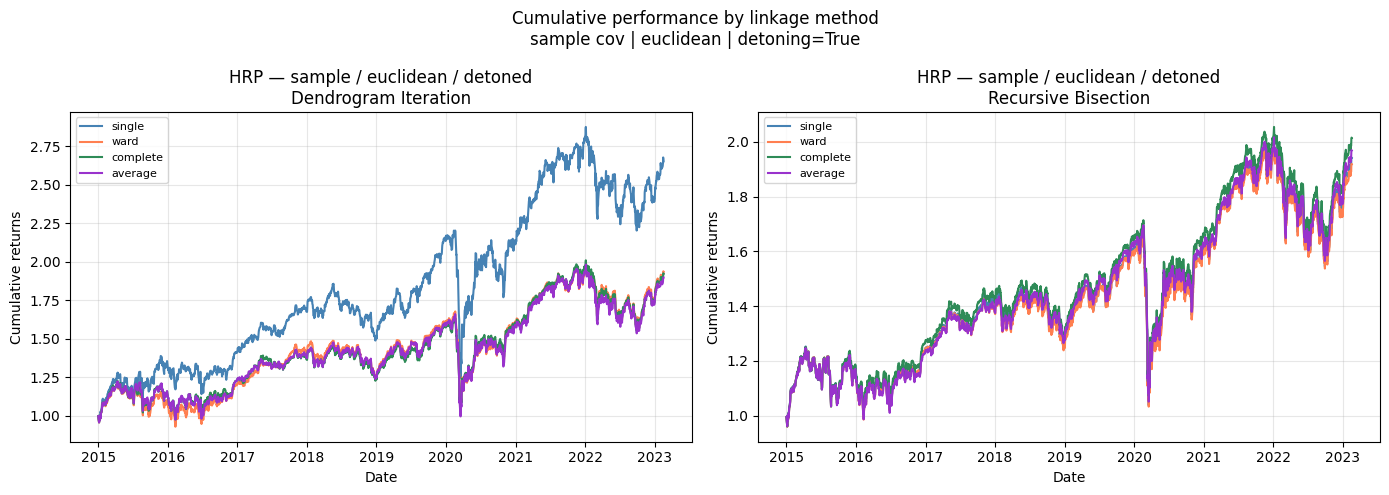

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

COLORS_LINK = {"single": "steelblue", "ward": "coral", 
               "complete": "seagreen", "average": "darkorchid"}

for ax, alloc_name in zip(axes, ["dendrogram_iteration", "recursive_bisection"]):
    for link, color in COLORS_LINK.items():
        key = ("sample", link, alloc_name, True)
        weights_df = pd.DataFrame(hrp_grid[key]).T
        weights_df.index = pd.to_datetime(weights_df.index)
        cum = backtest(weights_df.sort_index(), performance)
        ax.plot(cum.index, cum.values, color=color, lw=1.5, label=link)

    ax.set_title(f"HRP — sample / euclidean / detoned\n{ALLOC_TITLES[alloc_name]}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Cumulative returns")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle("Cumulative performance by linkage method\n"
             "sample cov | euclidean | detoning=True", fontsize=12)
plt.tight_layout()
plt.show()

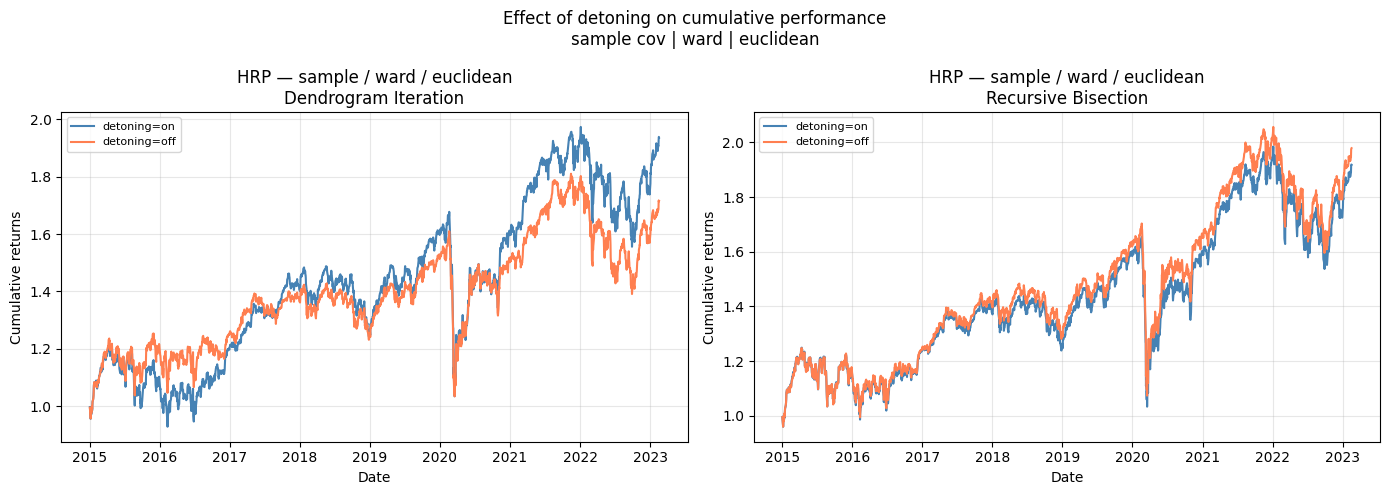

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

COLORS_DET = {True: "steelblue", False: "coral"}

for ax, alloc_name in zip(axes, ["dendrogram_iteration", "recursive_bisection"]):
    for det, color in COLORS_DET.items():
        key = ("sample", "ward", alloc_name, det)
        weights_df = pd.DataFrame(hrp_grid[key]).T
        weights_df.index = pd.to_datetime(weights_df.index)
        cum = backtest(weights_df.sort_index(), performance)
        ax.plot(cum.index, cum.values, color=color, lw=1.5,
                label=f"detoning={'on' if det else 'off'}")

    ax.set_title(f"HRP — sample / ward / euclidean\n{ALLOC_TITLES[alloc_name]}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Cumulative returns")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle("Effect of detoning on cumulative performance\n"
             "sample cov | ward | euclidean", fontsize=12)
plt.tight_layout()
plt.show()

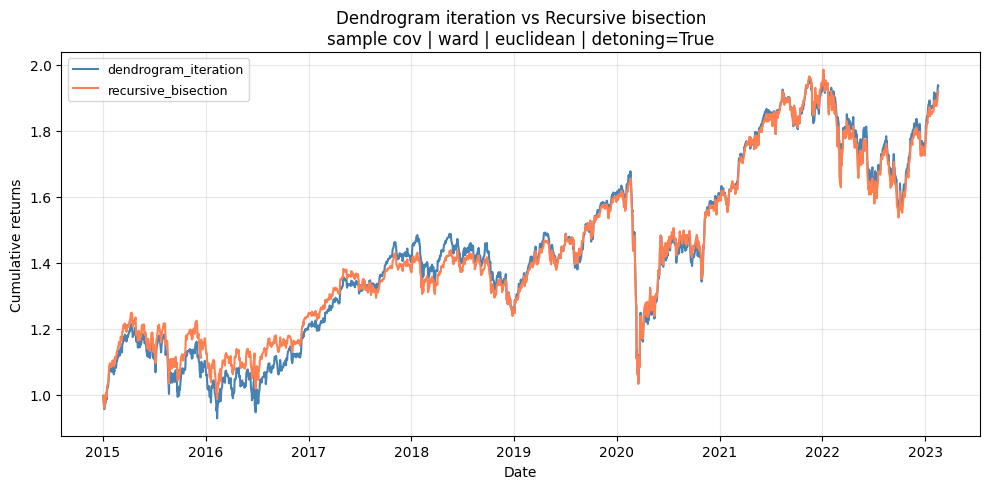

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))

COLORS_ALLOC = {"dendrogram_iteration": "steelblue", 
                "recursive_bisection":  "coral"}

for alloc_name, color in COLORS_ALLOC.items():
    key = ("sample", "ward", alloc_name, True)
    weights_df = pd.DataFrame(hrp_grid[key]).T
    weights_df.index = pd.to_datetime(weights_df.index)
    cum = backtest(weights_df.sort_index(), performance)
    ax.plot(cum.index, cum.values, color=color, lw=1.5, label=alloc_name)

ax.set_title("Dendrogram iteration vs Recursive bisection\n"
             "sample cov | ward | euclidean | detoning=True")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative returns")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

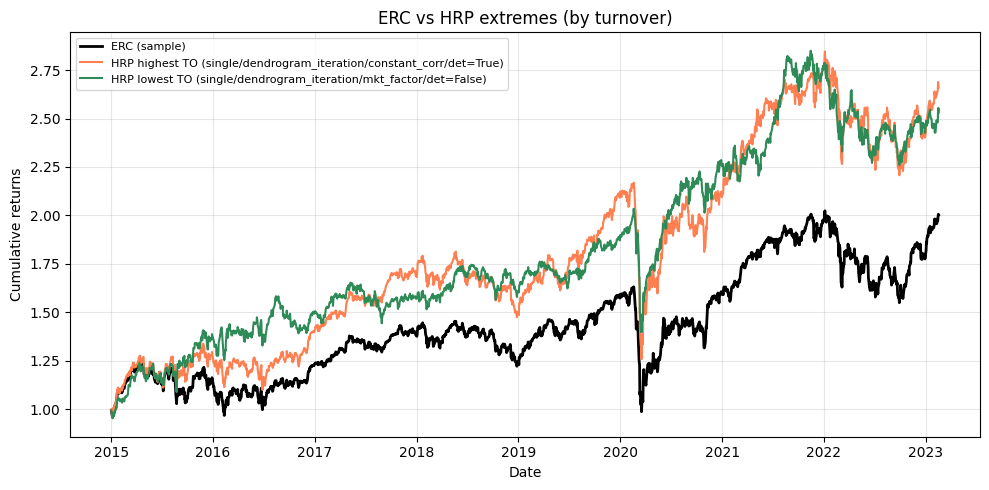

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))

# ERC sample
erc_w = pd.DataFrame(erc_portfolios["sample"]).T
erc_w.index = pd.to_datetime(erc_w.index)
ax.plot(backtest(erc_w.sort_index(), performance), 
        color="black", lw=2, label="ERC (sample)")

# Identifica best e worst HRP dal grid_df per Sharpe o total return
for (cov_key, link, alloc_name, det), wd in hrp_grid.items():
    weights_df = pd.DataFrame(wd).T
    weights_df.index = pd.to_datetime(weights_df.index)
    cum = backtest(weights_df.sort_index(), performance)
    # Etichetta solo best e worst dal grid_df
    row = grid_df[
        (grid_df.cov_key == cov_key) & (grid_df.linkage == link) &
        (grid_df.allocator == alloc_name) & (grid_df.detone == det)
    ]
    if row["mean_turnover"].values[0] == grid_df["mean_turnover"].min():
        ax.plot(cum.index, cum.values, color="seagreen", lw=1.5,
                label=f"HRP lowest TO ({link}/{alloc_name}/{cov_key}/det={det})")
    if row["mean_turnover"].values[0] == grid_df["mean_turnover"].max():
        ax.plot(cum.index, cum.values, color="coral", lw=1.5,
                label=f"HRP highest TO ({link}/{alloc_name}/{cov_key}/det={det})")

ax.set_title("ERC vs HRP extremes (by turnover)")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative returns")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Part III — Connecting the Dots


### 3.a ERC vs HRP — Robustness Against Estimator Choice

Mean L1 distance between weights — ERC vs HRP (ward / eucl / dendro / detoned)
                             ERC mean L1  HRP mean L1
Pair                                                 
sample vs constant_corr              0.0       0.2589
sample vs mkt_factor                 0.0       0.1663
constant_corr vs mkt_factor          0.0       0.2391
Average                              0.0       0.2214


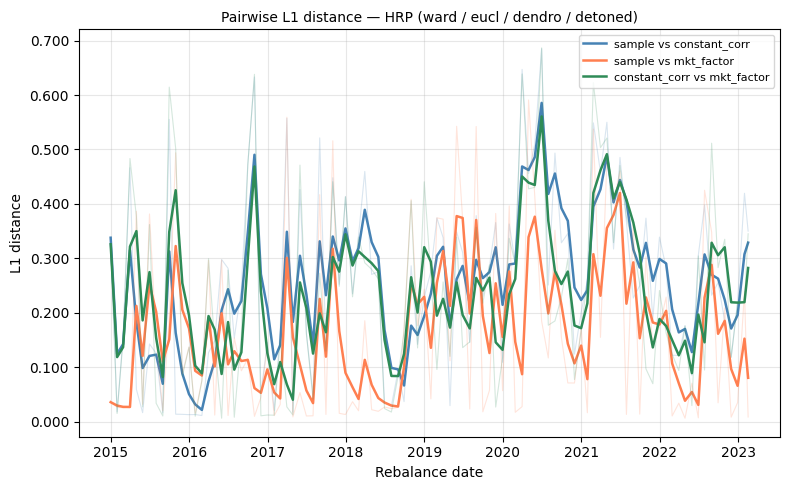

In [20]:
"""
Part III — Section 3.a
Robustness to covariance estimator choice: ERC vs HRP.

Representative HRP: ward / euclidean / dendrogram_iteration / detoning=True.
"""

import itertools
import matplotlib.ticker as mtick

# ── Configuration ─────────────────────────────────────────────────────────────

ESTIMATOR_PAIRS = list(itertools.combinations(["sample", "constant_corr", "mkt_factor"], 2))
PAIR_LABELS = {p: f"{p[0]} vs {p[1]}" for p in ESTIMATOR_PAIRS}

# Representative HRP: ward / euclidean / dendrogram_iteration / detoning=True
hrp_by_estimator = {
    "sample":        hrp_grid[("sample",        "ward", "dendrogram_iteration", True)],
    "constant_corr": hrp_grid[("constant_corr", "ward", "dendrogram_iteration", True)],
    "mkt_factor":    hrp_grid[("mkt_factor",    "ward", "dendrogram_iteration", True)],
}

# ── Helper functions ──────────────────────────────────────────────────────────

def l1_distance_between_portfolios(weights_a: pd.Series, weights_b: pd.Series) -> float:
    """
    L1 (Manhattan) distance between two weight vectors.
    Assets present in one portfolio but not the other (due to universe changes)
    are treated as having weight 0 in the absent series.
    """
    all_assets = weights_a.index.union(weights_b.index)
    wa = weights_a.reindex(all_assets, fill_value=0.0)
    wb = weights_b.reindex(all_assets, fill_value=0.0)
    return float((wa - wb).abs().sum())


def compute_pairwise_l1_series(
    portfolios_by_estimator: dict,
    pairs: list,
) -> dict:
    """
    For each pair of estimators, compute the time-series of L1 distances
    between the weights they produce on the common rebalance dates.
    """
    result = {}
    for est_a, est_b in pairs:
        port_a = portfolios_by_estimator[est_a]
        port_b = portfolios_by_estimator[est_b]
        common_dates = sorted(set(port_a.keys()) & set(port_b.keys()))
        result[(est_a, est_b)] = pd.Series(
            {d: l1_distance_between_portfolios(port_a[d], port_b[d])
             for d in common_dates},
            name=f"{est_a} vs {est_b}",
        )
    return result

# ── Compute L1 series ─────────────────────────────────────────────────────────

erc_l1_series = compute_pairwise_l1_series(erc_portfolios, ESTIMATOR_PAIRS)
hrp_l1_series = compute_pairwise_l1_series(hrp_by_estimator, ESTIMATOR_PAIRS)

# ── Summary table ─────────────────────────────────────────────────────────────

rows = []
for est_a, est_b in ESTIMATOR_PAIRS:
    label = f"{est_a} vs {est_b}"
    rows.append({
        "Pair":        label,
        "ERC mean L1": erc_l1_series[(est_a, est_b)].mean(),
        "HRP mean L1": hrp_l1_series[(est_a, est_b)].mean()
    })

summary = pd.DataFrame(rows).set_index("Pair")
summary.loc["Average"] = summary.mean()

print("=" * 75)
print("Mean L1 distance between weights — ERC vs HRP (ward / eucl / dendro / detoned)")
print("=" * 75)
print(summary.round(4).to_string())

# ── Time-series plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["steelblue", "coral", "seagreen"]

for color, (pair, series) in zip(colors, hrp_l1_series.items()):
    smoothed = series.ewm(span=3).mean()
    ax.plot(series.index, series.values, alpha=0.2, color=color, lw=0.8)
    ax.plot(smoothed.index, smoothed.values,
            label=PAIR_LABELS[pair], color=color, lw=1.8)

ax.set_title("Pairwise L1 distance — HRP (ward / eucl / dendro / detoned)", fontsize=10)
ax.set_xlabel("Rebalance date")
ax.set_ylabel("L1 distance")
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.3f"))
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 3.b ERC vs HRP — performance, vol, drawdown, turnover


Performance summary — ERC vs HRP
 Ann. Return Ann. Volatility Sharpe Ratio Max Drawdown Avg Monthly TO
Strategy     
ERC (sample) 8.75% 19.35% 0.452 -39.50% 0.0240
HRP (ward/eucl/dendro/detoned) 8.30% 18.93% 0.439 -38.29% 0.3567



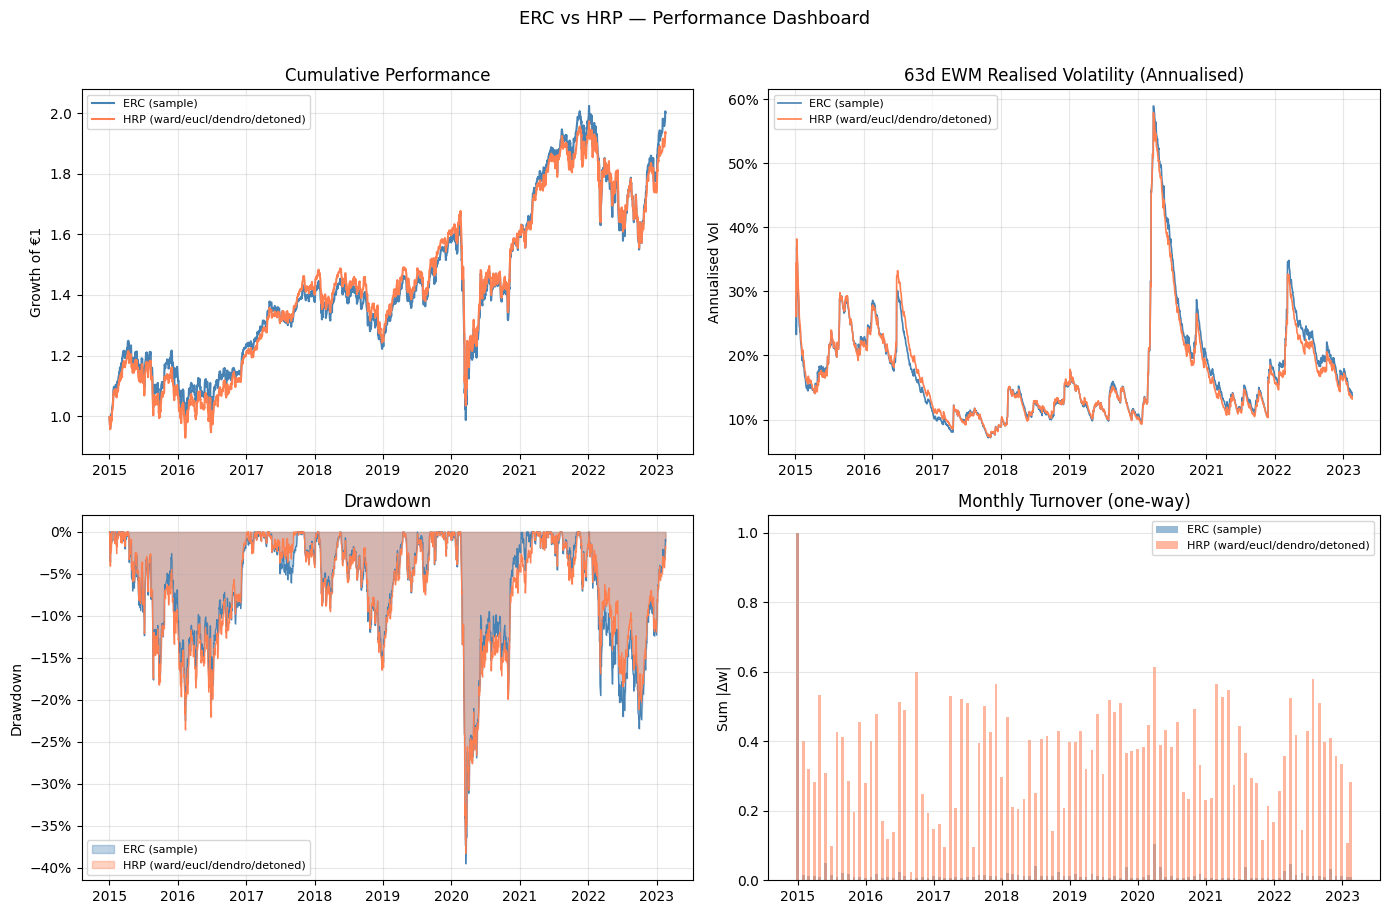

In [21]:
"""
Part III — Section 3.b
Head-to-head comparison: ERC (sample cov) vs HRP (ward / eucl / dendro / detoned, sample cov).
Metrics: cumulative performance, 63d EWM realised vol (annualised), drawdown, turnover.
"""

# ── Representative portfolios as DataFrames ───────────────────────────────────

def weights_dict_to_df(weights_dict: dict) -> pd.DataFrame:
    """
    Convert {date: pd.Series of weights} to a DataFrame (dates x assets),
    keeping only dates where the portfolio is non-empty.
    """
    df = pd.DataFrame(weights_dict).T
    df.index = pd.to_datetime(df.index)
    return df.sort_index()


# ERC with sample covariance (representative: robust to shrinkage as shown in 3.a)
erc_weights_df   = weights_dict_to_df(erc_portfolios["sample"])

# HRP representative: ward / euclidean / dendrogram_iteration / detoning=True / sample cov
hrp_weights_df   = weights_dict_to_df(hrp_grid[("sample", "ward", "dendrogram_iteration", True)])

# ── Metric helpers ────────────────────────────────────────────────────────────

def compute_turnover_series(weights_df: pd.DataFrame) -> pd.Series:
    """
    One-way turnover at each rebalance: sum of absolute weight changes
    between consecutive rebalance dates (universe changes handled via fillna).
    """
    aligned = weights_df.fillna(0.0)
    turnover = aligned.diff().abs().sum(axis=1)
    turnover.iloc[0] = aligned.iloc[0].abs().sum()   # first rebalance = full investment
    return turnover


def compute_drawdown(cum_returns: pd.Series) -> pd.Series:
    """Rolling drawdown from the running peak."""
    running_max = cum_returns.cummax()
    return (cum_returns - running_max) / running_max


def compute_ewm_vol(daily_returns: pd.Series, span: int = 63, trading_days: int = 252) -> pd.Series:
    """63-day EWM realised volatility, annualised."""
    return daily_returns.ewm(span=span).std() * np.sqrt(trading_days)


def performance_summary(label: str, cum_ret: pd.Series, daily_ret: pd.Series,
                         turnover: pd.Series) -> dict:
    """Scalar summary statistics for the report table."""
    ann_ret  = (cum_ret.iloc[-1] ** (252 / len(daily_ret)) - 1)
    ann_vol  = daily_ret.std() * np.sqrt(252)
    sharpe   = ann_ret / ann_vol if ann_vol > 0 else np.nan
    max_dd   = compute_drawdown(cum_ret).min()
    avg_to   = turnover.mean()
    return {
        "Strategy":          label,
        "Ann. Return":       ann_ret,
        "Ann. Volatility":   ann_vol,
        "Sharpe Ratio":      sharpe,
        "Max Drawdown":      max_dd,
        "Avg Monthly TO":    avg_to,
    }


# ── Compute daily returns ─────────────────────────────────────────────────────

erc_daily   = portfolio_returns(erc_weights_df,  performance)
hrp_daily   = portfolio_returns(hrp_weights_df,  performance)

erc_cum     = erc_daily.add(1).cumprod()
hrp_cum     = hrp_daily.add(1).cumprod()

erc_vol     = compute_ewm_vol(erc_daily)
hrp_vol     = compute_ewm_vol(hrp_daily)

erc_dd      = compute_drawdown(erc_cum)
hrp_dd      = compute_drawdown(hrp_cum)

erc_turnover = compute_turnover_series(erc_weights_df)
hrp_turnover_ = compute_turnover_series(hrp_weights_df)

# ── Summary table ─────────────────────────────────────────────────────────────

stats = pd.DataFrame([
    performance_summary("ERC (sample)",                    erc_cum, erc_daily, erc_turnover),
    performance_summary("HRP (ward/eucl/dendro/detoned)",  hrp_cum, hrp_daily, hrp_turnover_),
]).set_index("Strategy")

fmt = {
    "Ann. Return":      "{:.2%}",
    "Ann. Volatility":  "{:.2%}",
    "Sharpe Ratio":     "{:.3f}",
    "Max Drawdown":     "{:.2%}",
    "Avg Monthly TO":   "{:.4f}",
}
print("=" * 70)
print("Performance summary — ERC vs HRP")
print("=" * 70)
print(stats.style.format(fmt).to_string())

# ── Figure: 4-panel dashboard ─────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
colors = {"ERC": "steelblue", "HRP": "coral"}

# 1. Cumulative performance
ax = axes[0, 0]
ax.plot(erc_cum.index, erc_cum.values, color=colors["ERC"], lw=1.5, label="ERC (sample)")
ax.plot(hrp_cum.index, hrp_cum.values, color=colors["HRP"], lw=1.5,
        label="HRP (ward/eucl/dendro/detoned)")
ax.set_title("Cumulative Performance")
ax.set_ylabel("Growth of €1")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# 2. 63d EWM realised volatility (annualised)
ax = axes[0, 1]
ax.plot(erc_vol.index, erc_vol.values, color=colors["ERC"], lw=1.2, label="ERC (sample)")
ax.plot(hrp_vol.index, hrp_vol.values, color=colors["HRP"], lw=1.2,
        label="HRP (ward/eucl/dendro/detoned)")
ax.set_title("63d EWM Realised Volatility (Annualised)")
ax.set_ylabel("Annualised Vol")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# 3. Drawdown
ax = axes[1, 0]
ax.fill_between(erc_dd.index, erc_dd.values, 0,
                color=colors["ERC"], alpha=0.35, label="ERC (sample)")
ax.fill_between(hrp_dd.index, hrp_dd.values, 0,
                color=colors["HRP"], alpha=0.35, label="HRP (ward/eucl/dendro/detoned)")
ax.plot(erc_dd.index, erc_dd.values, color=colors["ERC"], lw=0.8)
ax.plot(hrp_dd.index, hrp_dd.values, color=colors["HRP"], lw=0.8)
ax.set_title("Drawdown")
ax.set_ylabel("Drawdown")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# 4. Monthly turnover
ax = axes[1, 1]
ax.bar(erc_turnover.index,  erc_turnover.values,  width=15,
       color=colors["ERC"], alpha=0.55, label="ERC (sample)")
ax.bar(hrp_turnover_.index,  hrp_turnover_.values,  width=15,
       color=colors["HRP"], alpha=0.55, label="HRP (ward/eucl/dendro/detoned)")
ax.set_title("Monthly Turnover (one-way)")
ax.set_ylabel("Sum |Δw|")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

plt.suptitle("ERC vs HRP — Performance Dashboard", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Comparison with Minimum Variance Portfolio

In [22]:
mv_portfolios = {"sample": {}, "constant_corr": {}, "mkt_factor": {}}

for reb in all_dates:
    universe = universes[reb]
    for est_name, cov in covariances[reb].items():
        weights = minimum_variance_portfolio(cov.values)
        mv_portfolios[est_name][reb] = pd.Series(weights, index=universe)

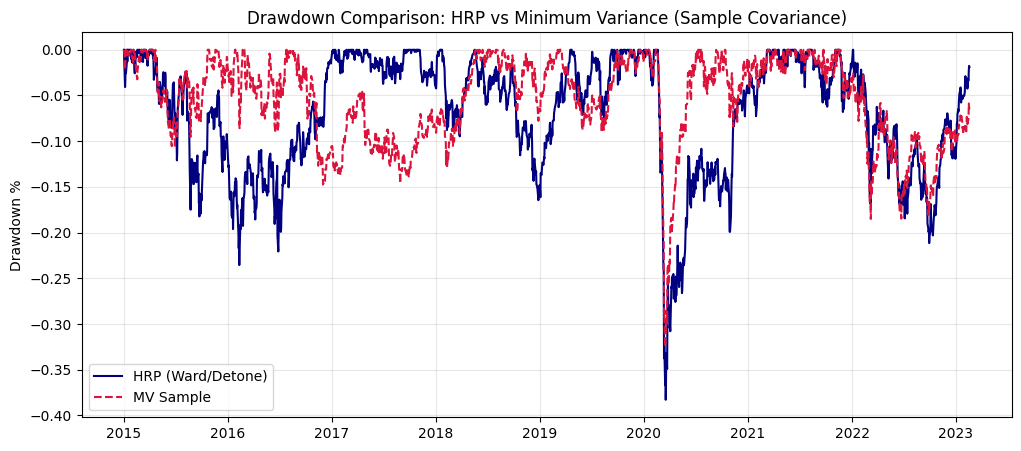

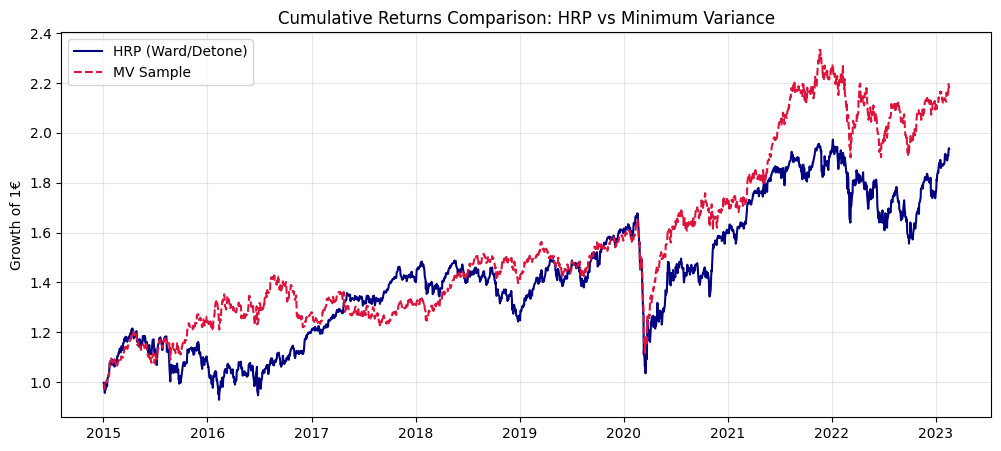

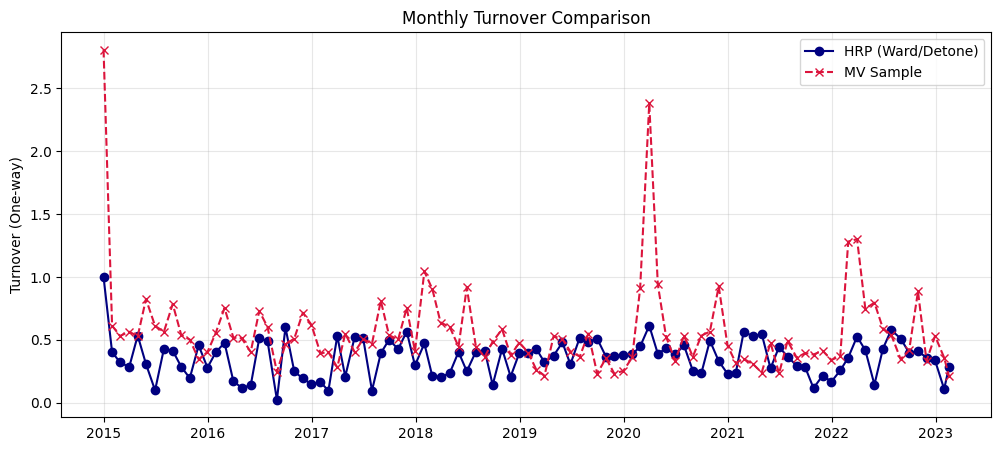

In [23]:
# 1. Prepare MV Sample Data
mv_sample_weights_df = weights_dict_to_df(mv_portfolios["sample"])
mv_sample_daily      = portfolio_returns(mv_sample_weights_df, performance)
mv_sample_cum        = mv_sample_daily.add(1).cumprod()
mv_sample_dd         = compute_drawdown(mv_sample_cum)
mv_sample_turnover   = compute_turnover_series(mv_sample_weights_df)

# 2. Plotting Max Drawdown
plt.figure(figsize=(12, 5))
plt.plot(hrp_dd, label='HRP (Ward/Detone)', color='navy')
plt.plot(mv_sample_dd, label='MV Sample', color='crimson', linestyle='--')
plt.title('Drawdown Comparison: HRP vs Minimum Variance (Sample Covariance)')
plt.ylabel('Drawdown %')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 3. Plotting Cumulative Returns
plt.figure(figsize=(12, 5))
plt.plot(hrp_cum, label='HRP (Ward/Detone)', color='navy')
plt.plot(mv_sample_cum, label='MV Sample', color='crimson', linestyle='--')
plt.title('Cumulative Returns Comparison: HRP vs Minimum Variance')
plt.ylabel('Growth of 1€')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 4. Plotting Turnover
plt.figure(figsize=(12, 5))
plt.plot(hrp_turnover_, label='HRP (Ward/Detone)', marker='o', color='navy')
plt.plot(mv_sample_turnover, label='MV Sample', marker='x', color='crimson', linestyle='--')
plt.title('Monthly Turnover Comparison')
plt.ylabel('Turnover (One-way)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

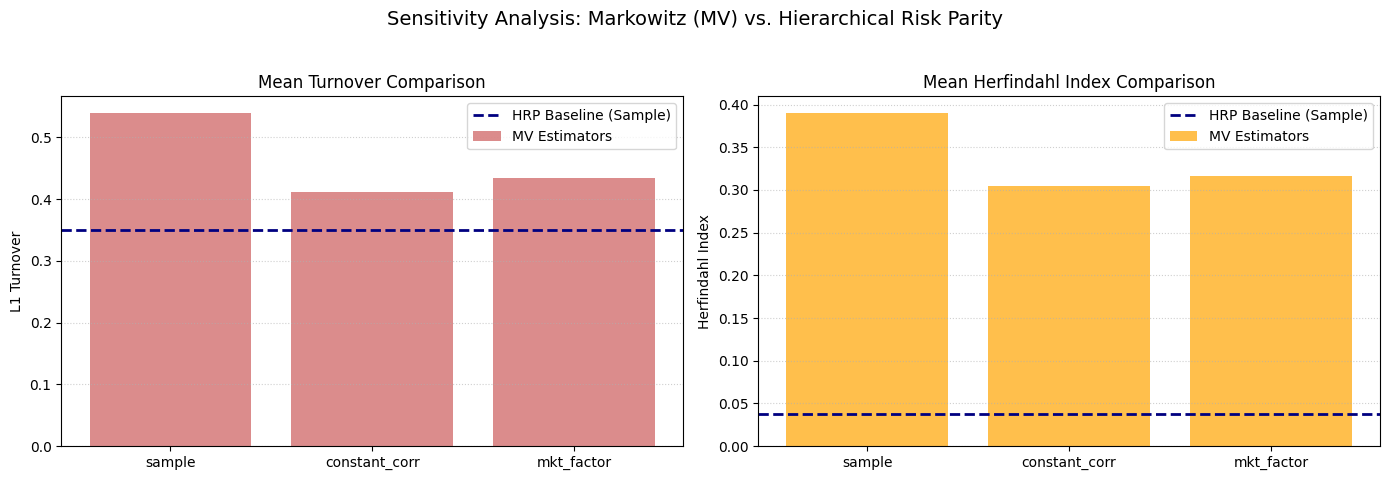

In [24]:
# --- Part III: Plotting MV vs HRP Sensitivity ---

mv_results = []
for est_name, wd in mv_portfolios.items():
    mv_results.append({
        "Estimator": est_name,
        "Turnover": hrp_turnover(wd),
        "Herfindahl": hrp_herfindahl(wd)
    })

mv_sens_df = pd.DataFrame(mv_results)

hrp_ref_row = grid_df[
    (grid_df['cov_key'] == 'sample') & 
    (grid_df['linkage'] == 'ward') & 
    (grid_df['allocator'] == 'dendrogram_iteration') & 
    (grid_df['detone'] == True)
]
hrp_ref_to = hrp_ref_row['mean_turnover'].values[0]
hrp_ref_herf = hrp_ref_row['mean_herfindahl'].values[0]

# 3. Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Turnover
axes[0].bar(mv_sens_df['Estimator'], mv_sens_df['Turnover'], color='indianred', alpha=0.7, label='MV Estimators')
axes[0].axhline(y=hrp_ref_to, color='navy', linestyle='--', linewidth=2, label='HRP Baseline (Sample)')
axes[0].set_title('Mean Turnover Comparison')
axes[0].set_ylabel('L1 Turnover')
axes[0].legend()
axes[0].grid(axis='y', linestyle=':', alpha=0.6)

# Plot Herfindahl (Concentrazione)
axes[1].bar(mv_sens_df['Estimator'], mv_sens_df['Herfindahl'], color='orange', alpha=0.7, label='MV Estimators')
axes[1].axhline(y=hrp_ref_herf, color='navy', linestyle='--', linewidth=2, label='HRP Baseline (Sample)')
axes[1].set_title('Mean Herfindahl Index Comparison')
axes[1].set_ylabel('Herfindahl Index')
axes[1].legend()
axes[1].grid(axis='y', linestyle=':', alpha=0.6)

plt.suptitle("Sensitivity Analysis: Markowitz (MV) vs. Hierarchical Risk Parity", fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()